In [58]:
from LiouvilleLanczos.Quantum_computer.Hamiltonian import Line_Hubbard, BoundaryCondition
from qiskit_nature.second_q.operators import FermionicOp
from LiouvilleLanczos.Quantum_computer.QC_lanczos import Liouvillian_spo, sum_spo, relative_simplify_spo, separate_imag, dump_qpu_error
from qiskit_ibm_runtime import RuntimeJobFailureError
from typing import Optional
from LiouvilleLanczos.Lanczos import Lanczos
import numpy as np
from qiskit.circuit.library import real_amplitudes
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from LiouvilleLanczos.Green import CF_Green as CF
from LiouvilleLanczos.Lanczos_components import Inner_product as Base_inner_product
from qiskit.primitives import BaseEstimatorV2
from qiskit.circuit.library import UnitaryGate
MAPPER = JordanWignerMapper()

In [59]:
def to_sparse_pauli(op):
    """
    Convert FermionicOp -> SparsePauliOp.
    Leave SparsePauliOp unchanged.
    """
    if isinstance(op, SparsePauliOp):
        return op

    if isinstance(op, FermionicOp):
        return MAPPER.map(op).simplify(atol=1e-12)

    raise TypeError(f"Unsupported operator type: {type(op)}")

def exact_gs_circuit_two_sites():
    bt = 0.7854074074074073
    GS_analytical = QuantumCircuit(4)
    GS_analytical.h(0)
    GS_analytical.x(1)
    GS_analytical.cx(0,1)
    GS_analytical.ry(bt,2)
    GS_analytical.x(3)
    GS_analytical.cx(2,3)
    GS_analytical.cx(1,3)
    GS_analytical.cx(1,2)
    GS_analytical.cz(1,2)
    GS_analytical.swap(1,2)
    return GS_analytical




Fermionic mode 0 = qubit 0
Fermionic mode 1 = qubit 1 and so on

In [60]:
for p in range(6):
    n_p = FermionicOp({f"+_{p} -_{p}": 1.0}, num_spin_orbitals=6)
    print(p, MAPPER.map(n_p))

0 SparsePauliOp(['IIIIII', 'IIIIIZ'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
1 SparsePauliOp(['IIIIII', 'IIIIZI'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
2 SparsePauliOp(['IIIIII', 'IIIZII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
3 SparsePauliOp(['IIIIII', 'IIZIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
4 SparsePauliOp(['IIIIII', 'IZIIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
5 SparsePauliOp(['IIIIII', 'ZIIIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])


In [61]:
U = 4 
q = 6

In [62]:
def hubbard(hop=np.array([[0, 1], [1, 0]]), u=4, mu=None):
    n = len(hop)
    if mu is None:
        mu = u / 2
    hopping = FermionicOp(
        {
            f"+_{i+m} -_{j+m}": hop[i, j]
            for m in [0, n]
            for i in range(n)
            for j in range(n)
            if hop[i, j] != 0
        },
        num_spin_orbitals=2 * n,
    )
    occupation = FermionicOp(
        {f"+_{i} -_{i}": 1 for i in range(2 * n)}, num_spin_orbitals=2 * n
    )
    interaction = FermionicOp(
        {f"+_{i} +_{i+n} -_{i+n} -_{i}": 1 for i in range(n)}, num_spin_orbitals=2 * n
    )
    return MAPPER.map(-hopping + u * interaction - mu * occupation)


n = 3
hopping = np.diag(np.ones(n - 1), 1) + np.diag(np.ones(n - 1), -1)
hamiltonian = hubbard(hopping, U, mu=U/2)
eigvals, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())

vqe_hubbard_3sites = real_amplitudes(num_qubits=6, reps=11, entanglement='linear')
vqe_hubbard_3sites = vqe_hubbard_3sites.assign_parameters(np.array([
    5.246829583426229, 1.8445563598975319, 6.249341224922228, 5.547426630865061, 4.204112886091582,
    4.7123853975763605, 0.27755320293694075, 0.32924783165591026, 1.5501725153481376, 0.354654347037912,
    1.4126950505240836, 7.524339982913663e-06, 1.5454883723953319, 4.008676262413297, 0.5471153440483539,
    0.6439116484454839, 5.416150750408826, 3.141590029386429, 1.121133004167295, 4.919561698711213,
    4.354025416990712, 4.348236205036469, 0.1627483139705849, 6.890458045940891e-06, 1.5750620500544459,
    3.925552761663296, 2.4735512439001406, 3.564021121427497, 2.1847082492649674, 3.1415875290047737,
    5.145406231818936, 3.082671747231, 4.755880471423207, 1.5314536798535008, 5.823307617043694,
    3.1416008591215223, 5.901892324799543, 1.4437881974849553, 4.645825634069647, 1.6387913496744664,
    5.2749649006268555, 1.1584242198623043e-05, 2.4788427008935474, 5.261826591438184, 5.982045041499495,
    2.24084148657242, 1.3918515401467277, 3.141590524117431, 2.6212585750135275, 0.0, 4.140488402169957,
    0.6887497275343819, 0.16071147559368984, 4.712382212081382, 5.6131238667553776, 0.2442058266515827,
    2.815716430300995, 1.696363607754504, 4.71239011907928, 6.283185307179586, 2.0669264858298853,
    2.441456446485303, 1.273233624886327, 2.646377569674503, 0.957628396457077, 1.8447208439653136,
    5.224543370694376, 1.583011829806925, 6.116083873171027, 6.0304071284479774e-06, 1.570785721175754,
    2.9229147479846883e-06
]))

vqe_energy = AerEstimatorV2().run([(vqe_hubbard_3sites, hamiltonian)]).result()[0].data.evs
vqe_state_vector = Statevector.from_instruction(vqe_hubbard_3sites)
vqe_fidelities = [
    float(np.abs(np.vdot(eigvecs[:, 0], vqe_state_vector)) ** 2),
    float(np.abs(np.vdot(eigvecs[:, 1], vqe_state_vector)) ** 2),
]

print(vqe_energy, eigvals[0], vqe_energy/eigvals[0], vqe_fidelities)


-7.236067977398462 -7.23606797749979 0.9999999999859969 [1.8090775811196553e-12, 0.9999999999494498]


In [ ]:
class inner_product_spo(Base_inner_product):
    """
    Operator Inner product implementation for sparse pauli operators.
    Compute $\\bra{\\psi} \\rho \\{A,B^\\dagger \\} \\ket{\\psi}$
    where $\\ket{\\psi}$ is a quantum state specified by a quantum circuit.
    $A$ and $B$ are quantum operators specified by sparse pauli operators.
    Uses ibm runtime estimatorV2 interface to submit tasks to quantum computers.
    """
    def __init__(self, state: QuantumCircuit, estimator: BaseEstimatorV2, epsilon: int, degen: bool = False):
        """
        Constructor for the inner product.
        requires
        - state: a quantum circuit that produce a desired state.
        - estimator: an EstimatorV2 estimator to submit jobs to a quantum computer.
        - epsilon: target accuracy, smaller relative values are truncated. 
        """
        self.state = state
        self.estimator = estimator
        self.eps = epsilon
        self.fswap = False
        if degen:
            FSWAP = np.array([
                [1, 0, 0,  0],
                [0, 0, 1,  0],
                [0, 1, 0,  0],
                [0, 0, 0, -1],
            ], dtype=complex)
        else:
            FSWAP = np.array([
                [1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, 0],
                [0, 0, 0, 1],
            ], dtype=complex)
        fswap_gate = UnitaryGate(FSWAP, label="FSWAP")
        self.GS_I = state.copy()
        self.GS_F = state.copy()
        self.GS_F.append(fswap_gate)
        
    def __call__(self,A:SparsePauliOp,B:SparsePauliOp,real_result:bool=False,Name:Optional[str]=None):
        """
        compute the innerproduct between that A and B operator.
        set real_result to True to bypass computation of an imaginary part in the result.
        Set a Name to easily identify the associated jobs on IBM quantum.
        """
        if self.fswap:
            GS = self.GS_F
        else:
            GS = self.GS_I
        Bc = B.adjoint()
        f = A@Bc+Bc@A
        f = relative_simplify_spo(f,self.eps)
        obs_real, obs_imag = separate_imag(f)        
        out = complex(0)
        if any(np.abs(obs_real.coeffs)>=self.eps):
            isa_obs_real = obs_real.apply_layout(GS.layout)
            try:
                out += np.real(self.estimator.run([(GS, isa_obs_real)]).result()[0].data.evs)
            except RuntimeJobFailureError as e:
                dump_qpu_error((GS, isa_obs_real), e, note="real")

        if not real_result and any(np.abs(obs_imag.coeffs)>=self.eps):
            isa_obs_imag = obs_imag.apply_layout(GS.layout)
            try:
                out_imag = np.real(self.estimator.run([(GS,isa_obs_imag)]).result()[0].data.evs)
            except RuntimeJobFailureError as e:
                dump_qpu_error((GS, isa_obs_imag), e, note="imag")
                
            out += out_imag * 1j
        fswap = not fswap
        return out

SyntaxError: invalid syntax (4259891372.py, line 46)

$$H = \sum_{i, j}\sum_{\sigma = \uparrow, \downarrow} t_{i, j} c_{i, \sigma}^\dagger
        c_{j, \sigma} + U \sum_{i} n_{i, \uparrow} n_{i, \downarrow}$$

In [64]:

Ham = Line_Hubbard(-1,U/2,U,int(q/2),boundary_condition=BoundaryCondition.OPEN)

C0 = FermionicOp(
    {
        "+_0": 1,
    },
    num_spin_orbitals=q,
)
print(Ham)
H = to_sparse_pauli(Ham)
C0 = to_sparse_pauli(C0)

Fermionic Operator
number spin orbitals=6, number terms=17
  -1 * ( +_0 -_2 )
+ 1 * ( -_0 +_2 )
+ -1 * ( +_2 -_4 )
+ 1 * ( -_2 +_4 )
+ -2.0 * ( +_0 -_0 )
+ -2.0 * ( +_2 -_2 )
+ -2.0 * ( +_4 -_4 )
+ -1 * ( +_1 -_3 )
+ 1 * ( -_1 +_3 )
+ -1 * ( +_3 -_5 )
+ 1 * ( -_3 +_5 )
+ -2.0 * ( +_1 -_1 )
+ -2.0 * ( +_3 -_3 )
+ -2.0 * ( +_5 -_5 )
+ 4 * ( +_0 -_0 +_1 -_1 )
+ 4 * ( +_2 -_2 +_3 -_3 )
+ 4 * ( +_4 -_4 +_5 -_5 )


This is (up,down,up,down,up,down)

In [65]:
FSWAP = np.array([
    [1, 0, 0,  0],
    [0, 0, 1,  0],
    [0, 1, 0,  0],
    [0, 0, 0, -1],
], dtype=complex)

fswap_gate = UnitaryGate(FSWAP, label="FSWAP")

In [ ]:
#GS = exact_gs_circuit_two_sites()

GS1 = vqe_hubbard_3sites.copy()
GS2 = GS1.copy()
GS2.append(fswap_gate, [0, 1])
GS2.append(fswap_gate, [2, 3])
GS2.append(fswap_gate, [4, 5])

GS = vqe_hubbard_3sites.copy()

In [67]:
eps = 1e-6
lanczos1 = Lanczos(inner_product_spo(GS1,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))
lanczos2 = Lanczos(inner_product_spo(GS2,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))


In [68]:
lanczos_result1 = lanczos1(H,C0,10,1e-8)
lanczos_result2 = lanczos2(H,C0,10,1e-8)

In [69]:
green1  = CF(lanczos_result1[0], lanczos_result1[1])
green2  = CF(lanczos_result2[0], lanczos_result2[1])

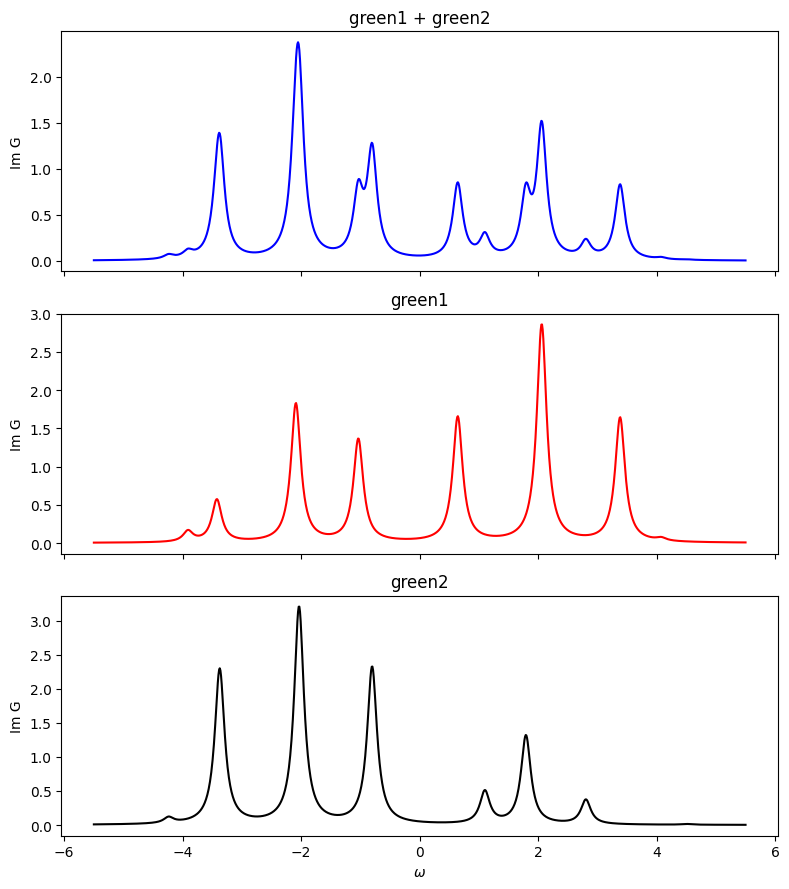

In [70]:
import matplotlib.pyplot as plt
import numpy as np

w = np.linspace(-5.5, 5.5, 1000) - 1e-1j
x = np.real(w)

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

axs[0].plot(x, 0.5 * np.imag(green1(w))+ 0.5 *np.imag(green2(w)), color="blue")
axs[0].set_title("green1 + green2")
axs[0].set_ylabel("Im G")

axs[1].plot(x, np.imag(green1(w)), color="red")
axs[1].set_title("green1")
axs[1].set_ylabel("Im G")

axs[2].plot(x, np.imag(green2(w)), color="black")
axs[2].set_title("green2")
axs[2].set_ylabel("Im G")
axs[2].set_xlabel(r"$\omega$")

plt.tight_layout()
plt.show()